# Lab7 - Noisy Annotators

Credits:

- the notebook is originally created by Daniel Kałuża
- modified and extended by Sebastian Stawicki and Piotr Biczyk

In real life annotation scenarios, we usually obtain annotations from multiple annotators. Moreover, we cannot assume that annotators are perfect, i.e. we know they certainly make mistakes. Moreover, their performance may vary, due to different levels of expertise, fatigue, or other factors. There can be even cases when the same expert annotates similar data differently, e.g., when the data is ambiguous or when the annotator is tired.

Therefore, during this lab session, we will focus on the problem of noisy annotations and how to deal with them to estimate the ground truth, e.g., using majority voting.

## 0. Import libraries

### Notation used throughout this notebook

- `N` = number of samples (70000 for MNIST)
- `K` = number of classes (10 - digits 0-9)
- `L` = number of annotators (15 for `tags`, 30 for `tags_hard`)

Prefer `tags.shape[1]`, `tags.shape[2]`, etc. to hard-coded numbers - it keeps your code working if you switch to `tags_hard`.

### Reproducibility

Section 5 involves random splits and repeated runs. Fix a seed *now* so that every experiment you run is reproducible. "Repeat 5 times" in Section 5 means 5 *different* seeds - not 5 runs with the same seed.

You can use something like:
```
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
```
and use rng for numpy operations. For sklearn, you can pass the integer seed directly via random_state.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

## 1. Data preparation

We will use MNIST dataset - the same as in one of the previous labs.

In [2]:
from sklearn.datasets import fetch_openml

bunch = fetch_openml('mnist_784', return_X_y=False)
X = bunch.data.to_numpy()
y = bunch.target.to_numpy()
y.shape
print(X.shape)


(70000, 784)


### One hot encoding of labels

We will assume that the annotators can label the samples with more than one class. This might reflect the annotators' uncertainty but still conveys valuable information, e.g., "It looks like the sample could be A, C, or D, but certainly not B or E".

Therefore, we will also transform our ground truth into an appropriate representation. Apply one-hot encoding to `y` so that the `i`-th element corresponding to a given sample is `1` if the sample belongs to class `i`, and `0` otherwise.

> **Heads-up:** `fetch_openml` returns MNIST labels as *strings* (`'0'`, `'1'`, ...), not integers. You'll need to cast them before one-hot encoding. E.g. gou can use `np.eye` for casting. Alternatively, `sklearn.preprocessing.LabelBinarizer` accepts strings directly.

In [3]:
# write your code here
from sklearn.preprocessing import OneHotEncoder

y = y.astype(int).reshape(-1, 1)    #Zamieniam y na typ int i zamieniam 1 wektor wielowymiarowy na wiele wektorów jednowymiarowych (dla OneHotEncoder)
enc = OneHotEncoder(sparse_output=False)
Y = enc.fit_transform(y).astype(int)    #One-Hot encoding

print(Y[:10])

[[0 0 0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]]


### Load the annotations

This time, instead of simulating the entire active learning annotation process, we will look at a particular state of our system. Specifically, we have a record of annotations up to a certain point in time.

There are `N = 70000` samples (MNIST images) in the dataset and there are `K` possible decision classes (`'0', '1', ..., '9'`). In our case, `L = 15` experts are involved in the annotation process. Each annotator can assign more than one class to a given sample, thereby expressing uncertainty in the assigned decision. Additionally, each sample may be labeled by one or more annotators, or not labeled at all.

We are going to use the annotations stored in the `Lab-07-noisy-annotators.npz` file. The `tags` array is of the shape `(N, K, L)` and it contains:

- `nan` if an annotator hasn't labelled this sample at all
- `0` if an annotator has labelled the sample and didn't indicate considered class
- `1` if an annotator has labelled the sample and indicated that it belongs to considered class

\* There is also a more challenging version stored under `tags_hard` variable, where there are `L = 30` experts involved in the labeling process.


In [4]:
noisy_annotators = np.load('Lab-07-noisy-annotators.npz')
tags = noisy_annotators['tags']
tags_hard = noisy_annotators['tags_hard']

print(f"Annotations (15 experts) shape: {tags.shape}")
print(tags[5:7, :, :])

Annotations (15 experts) shape: (70000, 10, 15)
[[[nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  1. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  1. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]
  [nan nan  0. nan nan nan nan nan nan nan nan nan nan nan nan]]

 [[nan nan nan  0. nan nan  0. nan nan nan nan nan nan nan nan]
  [nan nan nan  1. nan nan  1. nan nan nan nan nan nan nan nan]
  [nan nan nan  0. nan nan  0. nan nan nan nan nan nan nan nan]
  [nan nan nan  1. nan nan  0. nan nan nan nan nan nan nan nan]
  [nan nan nan  1. nan nan  0. nan nan nan nan nan nan

### Consistency rule for the `tags` array

For any fixed `(sample, expert)` pair, the K class slots (axis 1) are either:

- **all NaN** - the expert did not label this sample, or
- **all 0/1** - the expert labeled this sample and marked their chosen classes.

You never need to reason about mixed NaN/0 states *within* a single annotation. Practical consequence: to build an `(N, L)` mask of "did expert `j` annotate sample `i`?", you can slice just one class.

```python
annotated = ~np.isnan(tags[:, 0, :])
```

In [5]:
annotated = ~np.isnan(tags[:, 0, :])

print(np.sum(annotated))


38235


### Investigate the annotations

Some of the samples are not yet annotated, some are annotated by a single annotator and some by multiple annotators.

We can assume that the tags array is consistent, i.e., for a given sample and expert either all values are `nan` or all have `0/1` value.

1. Compute the number of samples tagged by each annotator and present the results as a bar plot. The x-axis should represent the ID of an expert, while the y-axis should represent the number of samples tagged by this expert.
2. Compute the average number of samples tagged by annotators.
3. Compute the number of samples annotated by `0, 1, 2, ..., L` annotators, and plot the results as a histogram. The x-axis should represent the number of annotators who labeled a sample, while the y-axis should represent the number of such samples (you might use logarithmic scale for the y-axis).

> **Performance note:** `N × K × L` is ~10.5M entries. Python `for` loops over samples will take minutes; vectorized NumPy takes milliseconds. If your code loops over samples, stop and rewrite using boolean masks, `np.isnan`, `.sum(axis=...)`, and `np.bincount`. 

> **Common pitfall:** for task 3, `plt.hist` with default bin edges will not align cleanly on integer values. Use `plt.bar(range(L+1), counts)` instead for a clean discrete-valued histogram.

(70000,)


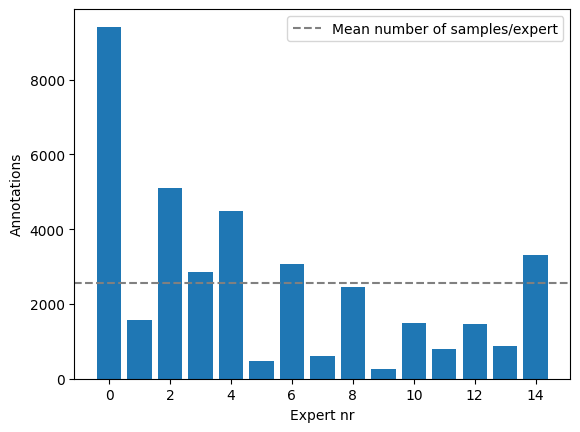

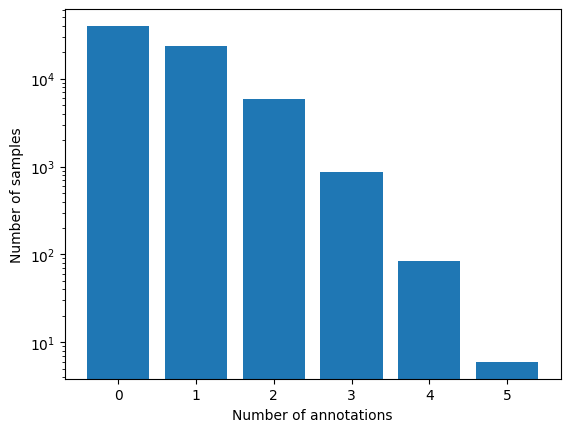

In [6]:
# write your code here
N, K, L = tags.shape

expert_annotations = np.sum(annotated, axis=0)  #ile póbek oznaczyli poszczególni eksperci
mean_expert_annotations = np.mean(expert_annotations)   #ile próbek średnio oznaczyli eksperci

annotated_by_l = np.sum(annotated, axis=1)      #ilu ekspertów rozważało daną próbkę
unique, annotations_counts = np.unique_counts(annotated_by_l)


print(annotated_by_l.shape)

plt.bar(np.arange(L), expert_annotations)
plt.xlabel("Expert nr")
plt.ylabel("Annotations")
plt.axhline(y=mean_expert_annotations, linestyle="--", color="gray", label="Mean number of samples/expert")
plt.legend()
plt.show()

plt.bar(unique, annotations_counts)
plt.xlabel("Number of annotations")
plt.ylabel("Number of samples")
plt.yscale("log")
plt.show()



(70000,)


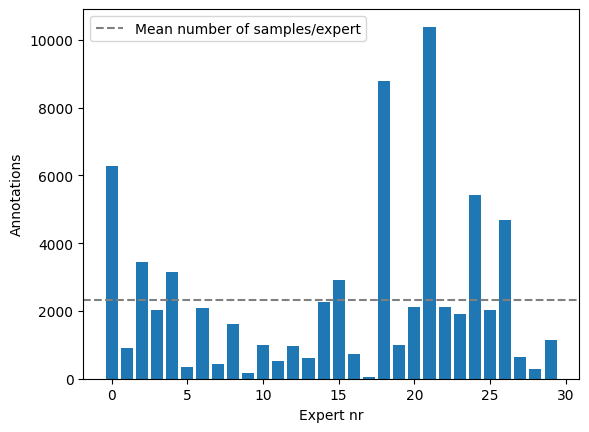

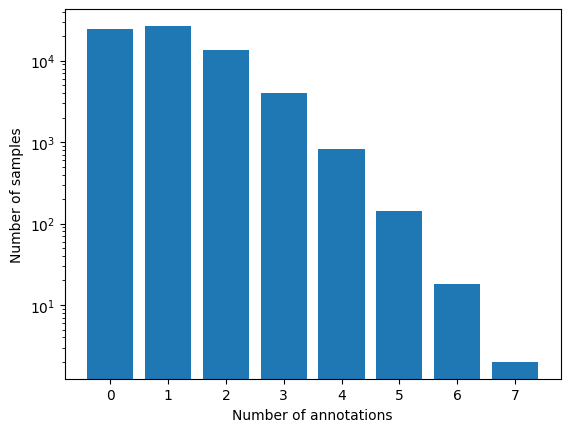

In [7]:
# write your code here
annotated_hard = ~np.isnan(tags_hard[:, 0, :])

L_hard=30
K=10
N=70000

expert_annotations_hard = np.sum(annotated_hard, axis=0)  #ile póbek oznaczyli poszczególni eksperci
mean_expert_annotations_hard = np.mean(expert_annotations_hard)   #ile próbek średnio oznaczyli eksperci

annotated_by_l_hard = np.sum(annotated_hard, axis=1)      #ilu ekspertów rozważało daną próbkę
unique_hard, annotations_counts_hard = np.unique_counts(annotated_by_l_hard)


print(annotated_by_l_hard.shape)

plt.bar(np.arange(L_hard), expert_annotations_hard)
plt.xlabel("Expert nr")
plt.ylabel("Annotations")
plt.axhline(y=mean_expert_annotations_hard, linestyle="--", color="gray", label="Mean number of samples/expert")
plt.legend()
plt.show()

plt.bar(unique_hard, annotations_counts_hard)
plt.xlabel("Number of annotations")
plt.ylabel("Number of samples")
plt.yscale("log")
plt.show()

### Sanity-check questions (answer in a markdown cell)

After producing the plots above, answer these briefly:

1. Roughly what fraction of samples have *zero* annotations? You'll train only on the annotated subset in Section 5 - knowing this number up front tells you how much data you'll lose.
2. Is the annotation workload roughly balanced across experts, or are some much more active than others?
3. Why did the prompt suggest a log-scale y-axis for the histogram? What does the shape of that distribution tell you about the annotation process?

### Optional: look at the hardest samples

A useful habit: find the samples where annotators disagreed most (e.g., highest vote spread or entropy across the K classes, considering only annotators who saw the sample). Plot the top 5 images alongside their vote distributions. You'll find they are often genuinely ambiguous digits. This builds intuition that "ground truth" itself is sometimes fuzzy.

### My answers

1. Roughly 4/7 of the samples have zero annotations (that is approx. 57%).
2. The experts were not equally involved in the labeling process, especially the first expert (expert ID = 0) was very active, while experts with IDs 5, 7 and 9 were not very active and annotated only a small fraction of the total number of annotated samples.
3. The prompt suggests using a log scale, because on such histogram she the height of the bars is better visible and it is easier to read it (at least the order of magnitude, where the number of annotations was the lowest). It also shows, that the probability of the sample being annotated by more experts decreases $\pm$ exponentially with the number of experts.

## 2. Evaluate the experts' performance

Create a function that evaluates the experts' performance. It should be possible to present the result in the graphical form.

The function should take the ground truth `y` labels (one-hot encoded), the `tags` array, and an additional `performance_fun` parameter. 

The performance function can be one of the following:

- `recall` - in multilabel version, we can count it as correct if the annotator assigns the right class (the same as the ground truth class) to the sample, even if multiple classes are assigned. We do not penalize the annotator if multiple wrong classes are also assigned,
- `precision`
- `hamming loss`

Implement all of them and, optionally, propose your own performance functions.

### Hints
Don't just call `sklearn.metrics.recall_score` and expect matching numbers. All these metrics should be computed **per annotator, only over the samples that annotator actually labeled** (NaN rows masked out).

- **Recall:** fraction of the annotator's labeled samples where the ground-truth class is included in the annotator's tag set, regardless of extra classes. Because ground truth is one-hot (exactly one positive per sample), this is effectively a per-sample hit/coverage rate averaged across labeled samples.
- **Precision:** per sample, of the classes the annotator tagged, how many match the truth - i.e., `(annotator ∩ truth) / |annotator|`. Averaged across the samples that annotator labeled. This penalizes extra wrong labels (unlike recall above).
- **Hamming loss:** fraction of `(sample, class)` slots where the annotator's tag differs from ground truth, across the samples they labeled.


Worth considering trying - beyond the three required metrics:

- Per-class recall per annotator - does annotator 3 struggle specifically with 4s and 9s? Real-world annotator QA almost always surfaces class-conditional weaknesses that scalar scores hide.
- A per-annotator confusion matrix (collapsing multi-label tags to their argmax or treating each tagged class as a vote).
- Expected calibration: when an annotator tags many classes, is the truth more likely to be among them?

In [8]:
def per_class_recall(true_labels, expert_tags):
    hit = (true_labels * expert_tags) > 0   # shape (n_samples, K)
    class_counts = true_labels.sum(axis=0)  # shape (K)
    # liczba trafień każdej klasy
    hits_per_class = hit.sum(axis=0)        # shape (K)
    # recall per class
    recall_per_class = np.divide(hits_per_class, class_counts, out=np.zeros_like(hits_per_class, dtype=float), where=class_counts != 0)
    return recall_per_class

def recall_fun(true_labels, expert_tags, average=True, per_class=False):
    if per_class:
        return per_class_recall(true_labels, expert_tags)
    else:
        hit = (true_labels * expert_tags).sum(axis=1) > 0
        return hit.mean() if average else hit


def precision_fun(true_labels, expert_tags, average=True):
    intersection = (true_labels * expert_tags).sum(axis=1)
    predicted = expert_tags.sum(axis=1)

    precision_sample = np.zeros_like(intersection, dtype=float)

    np.divide(intersection, predicted, out=precision_sample, where=predicted != 0)

    return precision_sample.mean() if average else precision_sample



def hamming_fun(true_labels, expert_tags, average=True):
    diff = (expert_tags != true_labels).mean(axis=1)
    return diff.mean() if average else diff



#testowanie funkcji
a = np.array([[0, 0, 1, 0],
              [0, 1, 0, 0]])

b = np.array([[1, 0, 1, 0],
              [0, 1, 0, 0]])

print(hamming_fun(a, b, average=False))


[0.25 0.  ]


In [9]:
# write your code here

def expert_performance(ground_y, tags, perf_fun, per_class=False):
    
    if per_class and perf_fun==recall_fun:
        expert_perf = np.zeros((tags.shape[2], ground_y.shape[1]))
    else:
        expert_perf = np.zeros(tags.shape[2])

    for expert in range(tags.shape[2]):
        annotated = ~np.isnan(tags[:, 0, expert])
        expert_tags = tags[annotated, :, expert]
        true_labels = ground_y[annotated]

        if per_class and perf_fun==recall_fun:
            expert_perf[expert] = perf_fun(true_labels, expert_tags, per_class=per_class)
        else:
            expert_perf[expert] = perf_fun(true_labels, expert_tags)

    return expert_perf


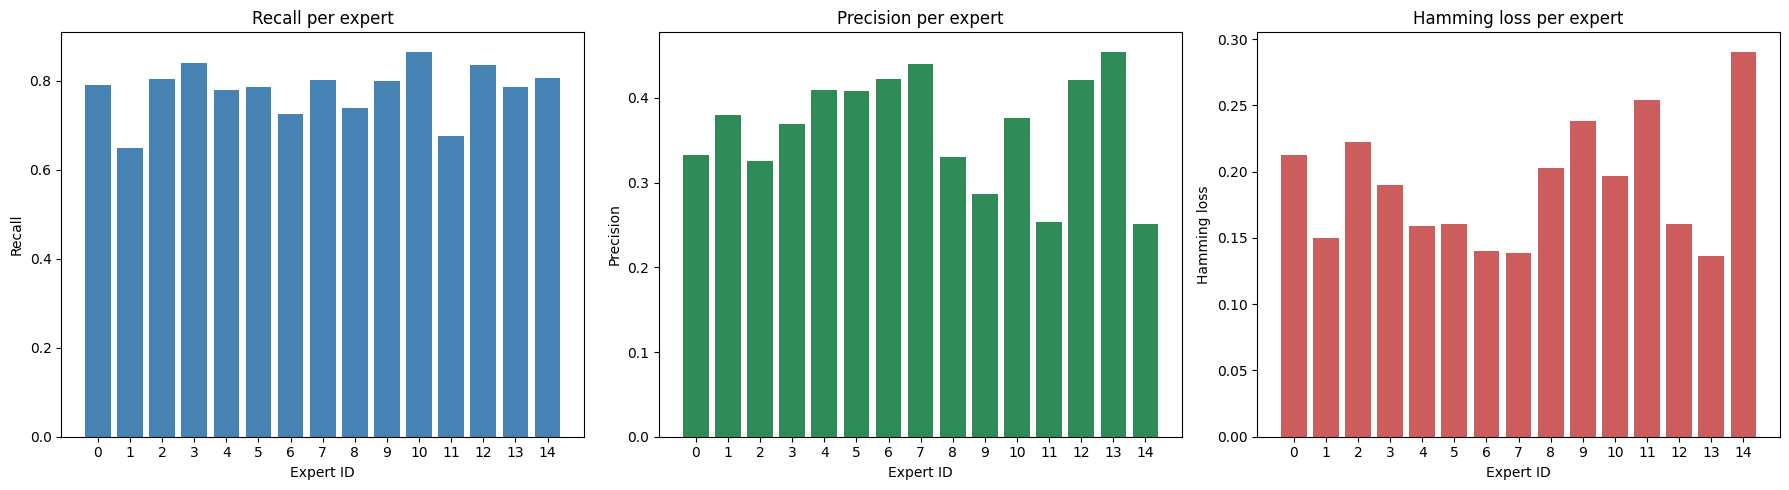

In [10]:
def plot_expert_metrics(ground_y, tags):
    L = tags.shape[2]
    recall_scores = expert_performance(ground_y, tags, recall_fun)
    precision_scores = expert_performance(ground_y, tags, precision_fun)
    hamming_scores = expert_performance(ground_y, tags, hamming_fun)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    # RECALL
    axes[0].bar(np.arange(L), recall_scores, color="steelblue")
    axes[0].set_title("Recall per expert")
    axes[0].set_xlabel("Expert ID")
    axes[0].set_ylabel("Recall")
    axes[0].set_xticks(np.arange(L))

    # PRECISION
    axes[1].bar(np.arange(L), precision_scores, color="seagreen")
    axes[1].set_title("Precision per expert")
    axes[1].set_xlabel("Expert ID")
    axes[1].set_ylabel("Precision")
    axes[1].set_xticks(np.arange(L))

    #HAMMING LOSS
    axes[2].bar(np.arange(L), hamming_scores, color="indianred")
    axes[2].set_title("Hamming loss per expert")
    axes[2].set_xlabel("Expert ID")
    axes[2].set_ylabel("Hamming loss")
    axes[2].set_xticks(np.arange(L))

    plt.tight_layout()
    plt.show()

plot_expert_metrics(Y, tags)

Eksperci w analizowanym zbiorze danych okazali się stosunkowo czuli, ale mało precyzyjni. Wysoki poziom recall (zwykle 0.6–0.8) oznacza, że eksperci rzadko pomijają prawdziwą klasę i zazwyczaj umieszczają ją wśród swoich etykiet. Jednocześnie niska precision (około 0.25–0.40) pokazuje, że często oznaczają zbyt wiele klas naraz, co prowadzi do dużej liczby fałszywych pozytywów. Hamming loss na poziomie 0.15–0.20 potwierdza, że ich adnotacje są dość hałaśliwe i niespójne, a jakość poszczególnych ekspertów wyraźnie się różni.

W praktyce oznacza to, że eksperci dostarczają użytecznych informacji (prawdziwa klasa zwykle znajduje się wśród ich oznaczeń), ale ich etykiety zawierają dużo szumu i niepewności, co może ograniczać ich użyteczność do skutecznego trenowania modeli uczenia maszynowego.

## 3. Majority voting scheme

Implement the majority voting algorithm. Estimate the ground truth by choosing the class with the highest number of votes among the experts that annotated the sample. Implement two versions for tie handling - either choose the class with the lowest index or mark several classes as the ground truth. If no annotator has labeled the sample, set `nan` values. The result should be a 2D array of shape `(N, K)`.

##### Careful with three distinct states

After summing votes across annotators (e.g., `np.nansum(tags, axis=2)`), you get an `(N, K)` array of vote counts. But this collapses two *very different* cases to zero:

1. **No annotator saw this sample at all** → output should be NaN.
2. **Annotators saw it, but none voted for class `k`** → output is a legitimate zero.

Keep a separate mask to distinguish them, and set the rows where your mask returns is `False` to NaN in your final output.

##### Tie-breaking tricks

- **Version 1 (lowest index wins):** `np.argmax` already returns the lowest index on ties, so this is nearly a one-liner on the vote-count array.
- **Version 2 (mark all top classes):** `votes == votes.max(axis=1, keepdims=True)` gives a boolean mask of all classes tied for first place. **Important:** apply this *only after* masking/zeroing the no-annotation rows. Otherwise, `max` of an all-zeros row is 0, every class ties for first, and you get rows full of 1s where you wanted NaN.

##### Output dtype note

Because unannotated rows must be NaN, the output must be `float` - you can't use an integer dtype. This matters in Section 5 when you feed labels to a classifier.

##### Why would majority voting even work?

This is [Condorcet's Jury Theorem](https://en.wikipedia.org/wiki/Condorcet%27s_jury_theorem): if each voter is independently better than random, aggregate accuracy grows with the number of voters. Two assumptions to keep in mind when evaluating MV in the next section:

1. Are annotators *better than random*? (We hope so - Section 2 tells you.)
2. Are their errors *independent*? (Almost certainly not - a blurry 4 looks like a 9 to most people. Correlated errors weaken MV.)

In [11]:
# write your code here


def majority_vote(tags, mode="argmax"):
    #czy jakiś ekspert oznaczył próbkę?
    annotated_mask = ~np.isnan(tags[:, 0, :]).all(axis=1)   # shape (N)
    #sumujemy po ekspertach, nan ignorowane
    votes = np.nansum(tags, axis=2)   # shape (N, K)
    result = np.zeros((tags.shape[0:2]), dtype=float)

    if mode=="argmax":
        result = np.zeros((tags.shape[0:2]), dtype=float)
        winner = np.argmax(votes[annotated_mask], axis=1)
        #wstawiamy 1 w odpowiednich miejscach
        result[annotated_mask, winner] = 1

    elif mode=="multilabel":
        #dla oznaczonych próbek liczymy max
        votes_annot = votes[annotated_mask]
        #maska klas, które mają max głosów
        top_mask = votes_annot == votes_annot.max(axis=1, keepdims=True)
        #wstawiamy 1 dla wszystkich klas z remisu
        result[annotated_mask] = top_mask.astype(float)
    else:
        print("Invalid mode! Only 'argmax' and 'multilabel' are valid mode arguments!")
        return
    
    #Próbki nieoznaczone -> NaN
    result[~annotated_mask, :] = np.nan
    return result


sample = np.array([ [[np.nan, np.nan, np.nan],
            [np.nan, np.nan, np.nan],
            [np.nan, np.nan, np.nan]],
              
            [[np.nan, 1, 0],
            [np.nan, 0, 1],
            [np.nan, 1, 0]] ])

print(majority_vote(sample, mode="multilabel"))




[[nan nan nan]
 [ 1.  1.  1.]]


## 4. Performance of the majority voting approach

Evaluate the performance of the majority voting algorithm. E.g., if you add an artificial dimension (`(N, K) -> (N, K, 1)`) to the resulting array, you could use the `evaluate_experts_performance`. 

You could think of the result as labels of an additional annotator. Compare the performance of the majority voting algorithm with the performance of the annotators.

### Things to consider:
##### What to plot

On one figure, show MV's score alongside *all* 15 individual annotators' scores (16 bars, MV highlighted in a distinct color). The interesting question is not "does MV beat the average annotator?" - it usually does - but **does MV beat the *best* individual annotator?** That's the non-trivial claim of the Condorcet theorem.

##### Error analysis

Build a confusion matrix of MV predictions vs. ground truth on the samples where MV produced a single-class answer. Look for the classic MNIST hard pairs (4/9, 3/5, 7/1). Scalar metrics hide this structure, but it's often where the interesting errors live.

##### MV is a floor, not a ceiling

Majority voting weights all annotators equally and ignores per-annotator reliability. The classical next step is [Dawid & Skene (1979)](https://www.jstor.org/stable/2346806), which jointly estimates each annotator's confusion matrix and the latent labels via EM. Modern libraries like [crowd-kit](https://github.com/Toloka/crowd-kit) implement Dawid-Skene, GLAD, MACE, and others in a few lines. If you finish the main lab early, try running Dawid-Skene on this data and compare to MV.

##### Worth computing: inter-annotator agreement

[Fleiss' kappa](https://en.wikipedia.org/wiki/Fleiss%27_kappa) quantifies how much agreement between annotators exceeds chance. In production, you'd usually compute this *before* trusting any aggregation method - if annotators barely agree above chance, no amount of voting will save you. `statsmodels.stats.inter_rater.fleiss_kappa` implements it.

In [12]:
# write your code here
MV_results = majority_vote(tags, mode="argmax")
MV_results_exp = np.expand_dims(MV_results, axis=2)
MV_performance_recall = expert_performance(Y, MV_results_exp, perf_fun=recall_fun)
MV_performance_precision = expert_performance(Y, MV_results_exp, perf_fun=precision_fun)
MV_performance_hamming = expert_performance(Y, MV_results_exp, perf_fun=hamming_fun)

exp_performance_recall = expert_performance(Y, tags, perf_fun=recall_fun)
exp_performance_precision = expert_performance(Y, tags, perf_fun=precision_fun)
exp_performance_hamming = expert_performance(Y, tags, perf_fun=hamming_fun)
print(MV_performance_recall)
print(MV_performance_precision)
print(MV_performance_hamming)



[0.40230909]
[0.40230909]
[0.11953818]


Majority voting mode: argmax


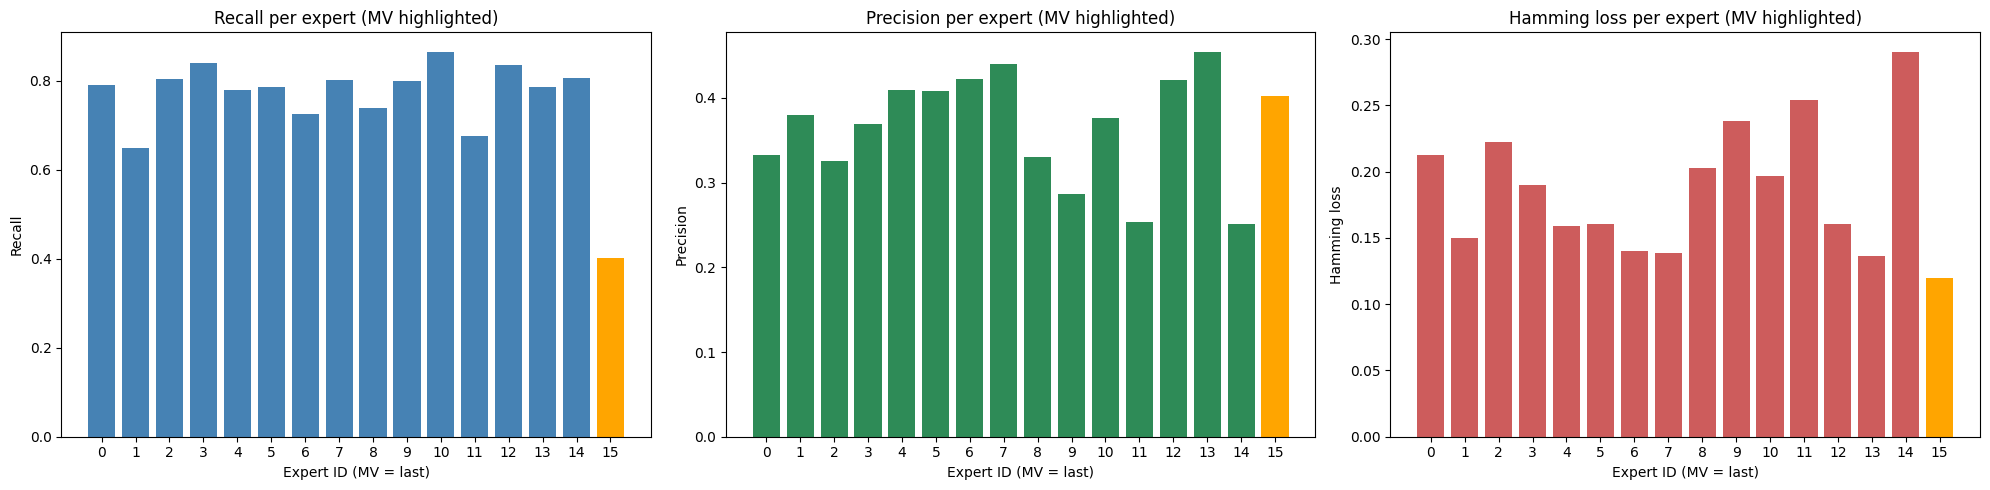

Majority voting mode: multilabel


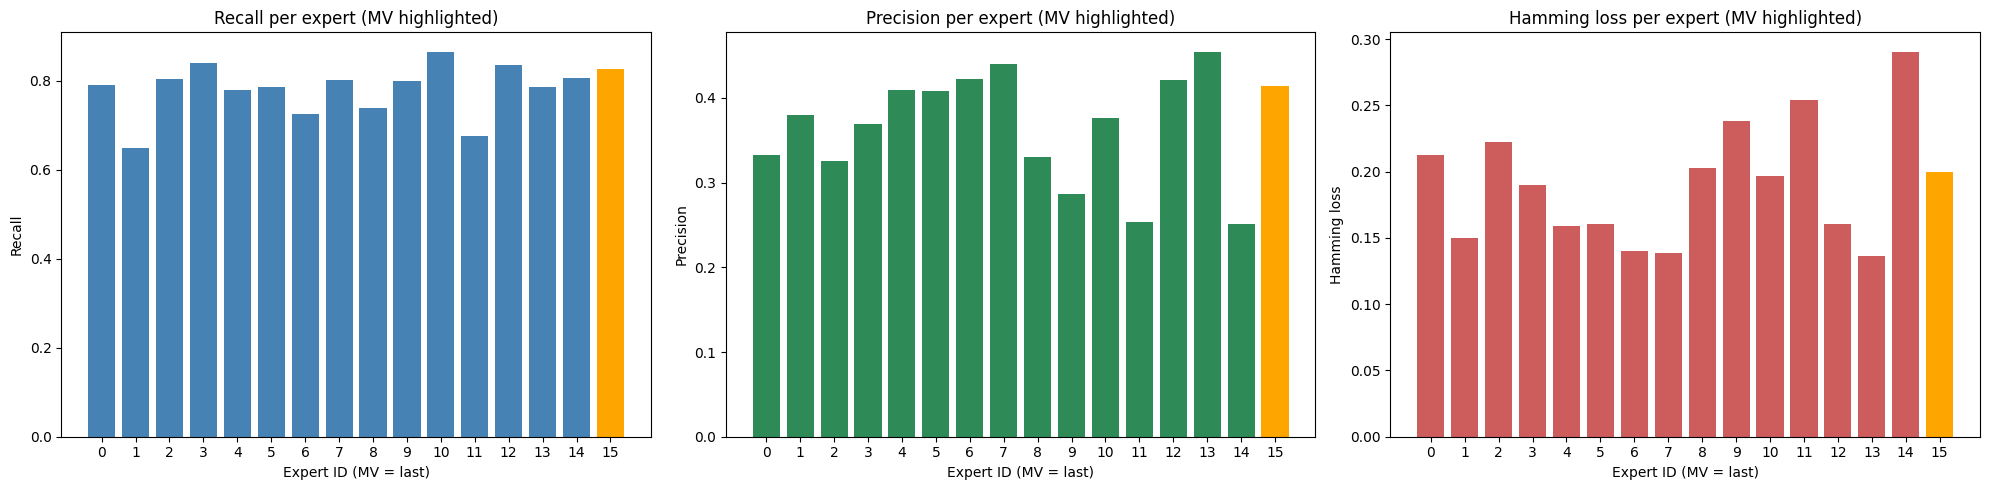

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def plot_expert_metrics_with_mv(ground_y, tags, mode="argmax"):
    """
    ground_y : (N, K)
    tags     : (N, K, L)       - eksperci
    mv_tags  : (N, K, 1)       - majority voting jako dodatkowy ekspert
    """
    mv_tags = np.expand_dims(majority_vote(tags, mode=mode), axis=2)

    # Połącz ekspertów + MV jako "eksperta nr L"
    tags_all = np.concatenate([tags, mv_tags], axis=2)
    L_all = tags_all.shape[2]   # L + 1

    # Obliczamy metryki
    recall_scores   = expert_performance(ground_y, tags_all, recall_fun)
    precision_scores = expert_performance(ground_y, tags_all, precision_fun)
    hamming_scores   = expert_performance(ground_y, tags_all, hamming_fun)

    # Ostatni indeks to MV
    mv_index = L_all - 1

    # Kolory: eksperci = szare, MV = wyróżniony
    colors_recall   = ["steelblue"] * mv_index + ["orange"]
    colors_precision = ["seagreen"] * mv_index + ["orange"]
    colors_hamming   = ["indianred"] * mv_index + ["orange"]

    # Rysowanie
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    x = np.arange(L_all)

    #RECALL
    axes[0].bar(x, recall_scores, color=colors_recall)
    axes[0].set_title("Recall per expert (MV highlighted)")
    axes[0].set_xlabel("Expert ID (MV = last)")
    axes[0].set_ylabel("Recall")
    axes[0].set_xticks(x)

    #PRECISION
    axes[1].bar(x, precision_scores, color=colors_precision)
    axes[1].set_title("Precision per expert (MV highlighted)")
    axes[1].set_xlabel("Expert ID (MV = last)")
    axes[1].set_ylabel("Precision")
    axes[1].set_xticks(x)

    #HAMMING LOSS
    axes[2].bar(x, hamming_scores, color=colors_hamming)
    axes[2].set_title("Hamming loss per expert (MV highlighted)")
    axes[2].set_xlabel("Expert ID (MV = last)")
    axes[2].set_ylabel("Hamming loss")
    axes[2].set_xticks(x)

    plt.tight_layout()
    print(f"Majority voting mode: {mode}")
    plt.show()

plot_expert_metrics_with_mv(Y, tags, mode="argmax")
plot_expert_metrics_with_mv(Y, tags, mode="multilabel")


Wyniki majority voting pokazują, że agregacja etykiet ekspertów pozwala uzyskać jakość nieco wyższą niż przeciętny annotator, ale nadal wyraźnie gorszą niż najlepsi eksperci indywidualnie. Zarówno w wariancie 'argmax', jak i 'multilabel', MV osiąga umiarkowany recall i precision, co odzwierciedla fakt, że eksperci często oznaczają wiele klas naraz i popełniają wiele błędów. Majority voting poprawia stabilność i redukuje część przypadkowych pomyłek, ale nie jest w stanie skompensować systematycznych błędów popełnianych przez większość annotatorów (np. mylenie tych samych par cyfr). W efekcie MV działa jako nieco lepszy „średni” ekspert. Radzi sobie lepiej od słabszych annotatorów, ale nie przewyższa najlepszych. Proste głosowanie większościowe jest użyteczne jako baseline, lecz nie stanowi metody wystarczająco silnej, aby w pełni wykorzystać dostępne dane.

### Confusion matrix

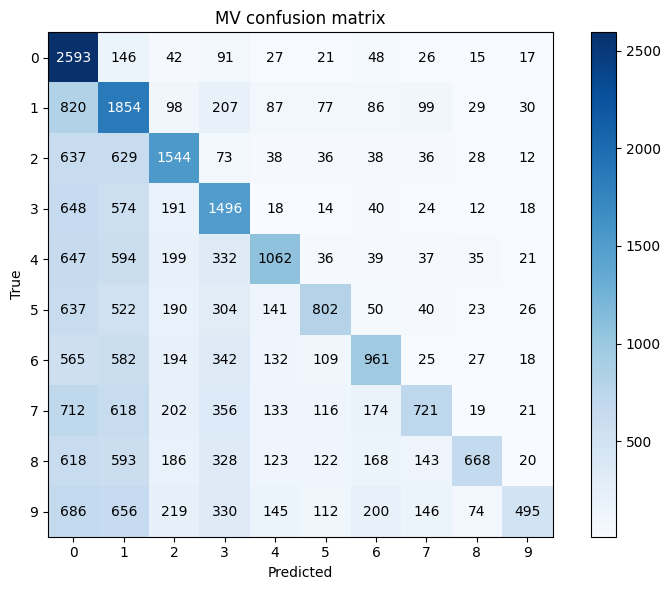

In [14]:
def mv_confusion_matrix(ground_y, mv_tags):
    """
    ground_y : (N, K) one-hot ground truth
    mv_tags  : (N, K) majority voting output (argmax mode)
    """
    #czy MV zawsze wskazuje dokładnie jedną klasę?
    mask = ~np.isnan(mv_tags[:, 0])
    #print(mask)

    y_true = ground_y[mask].argmax(axis=1)
    y_pred = mv_tags[mask].argmax(axis=1)
    #print(y_true)
    #print(y_pred)

    K = ground_y.shape[1]
    cm = np.zeros((K, K), dtype=int)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    return cm

def plot_confusion_matrix(cm, title="MV confusion matrix"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()

    K = cm.shape[0]
    plt.xticks(np.arange(K))
    plt.yticks(np.arange(K))

    # wartości w komórkach
    for i in range(K):
        for j in range(K):
            plt.text(j, i, cm[i, j], ha="center", va="center",
                     color="black" if cm[i, j] < cm.max()/2 else "white")

    plt.tight_layout()
    plt.show()


MV_cm = mv_confusion_matrix(Y, MV_results)

#print(MV_cm)
plot_confusion_matrix(MV_cm)


Confusion matrix dla majority voting w trybie argmax pokazuje wyraźną nadreprezentację klas o niskich indeksach, szczególnie cyfr 0 i 1. Wynika to z faktu, że eksperci często oznaczali wiele klas jednocześnie, a w przypadku remisów algorytm argmax zawsze wybiera klasę o najniższym indeksie. W efekcie nawet wtedy, gdy eksperci nie byli zgodni, przewidywana etykieta była systematycznie przesuwana w stronę klas 0-1. Macierz błędów ujawnia również typowe dla MNIST trudne pary (np. 4/9, 3/5, 7/1), które eksperci mylili konsekwentnie, co dodatkowo obniża jakość majority voting. Ogólnie MV poprawia stabilność względem pojedynczych annotatorów, ale nie eliminuje ich skorelowanych błędów i wprowadza własne uprzedzenia wynikające z mechanizmu  rozstrzygania sytuacji remisowych.

### Experymenty z crowd-kit

In [15]:
import pandas as pd
import numpy as np
import tqdm
from crowdkit.aggregation import DawidSkene

# 1. Maska próbek oznaczonych przez ekspertów
annotated_mask = ~np.isnan(tags[:, 0, :]).all(axis=1)

Y_masked = Y[annotated_mask]
tags_masked = tags[annotated_mask]

# 2. Konwersja do crowd-kit
def convert_to_crowdkit(tags):
    N, K, L = tags.shape
    rows = []
    for worker in range(L):
        for task in range(N):
            labels = np.where(tags[task, :, worker] == 1)[0]
            for label in labels:
                rows.append((task, worker, label))
    return pd.DataFrame(rows, columns=["task", "worker", "label"])

df = convert_to_crowdkit(tags_masked)

# 3. Dawid–Skene
ds = DawidSkene(n_iter=50)
ds_labels = ds.fit_predict(df)

# 4. One-hot
K = tags.shape[1]
ds_onehot = np.eye(K)[ds_labels]

# 5. Pobieramy taski, które crowd-kit faktycznie wykorzystał
used_tasks = np.sort(df["task"].unique())

# 6. Dopasowujemy ground truth
Y_used = Y_masked[used_tasks]

# 7. Metryki
recall_ds = recall_fun(Y_used, ds_onehot)
precision_ds = precision_fun(Y_used, ds_onehot)
hamming_ds = hamming_fun(Y_used, ds_onehot)

print("Recall DS:", recall_ds)
print("Precision DS:", precision_ds)
print("Hamming DS:", hamming_ds)


C:\Users\elg23\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Recall DS: 0.10375924612422738
Precision DS: 0.10375924612422738
Hamming DS: 0.17924815077515452


## 5. Train a model on the estimated labels

Perform a random train-test (80-20) split of the dataset. 

Choose an ML algorithm and prepare two models. To make the comparison fair, use only those samples from the training subset that are annotated by at least one annotator:

- train a model using the ground truth labels,
- train a model using the labels estimated by the majority voting algorithm.

Evaluate the models on the test subset (using the ground truth labels). Repeat the process `5` times, compute the average score and standard deviation values. Present the results using a bar plot with error bars. 

Repeat the comparison/evaluation using cross-validation.

### Things to consider:

##### Order matters: split first, filter second

Do the train/test split on the *full* 70k dataset first, then drop unannotated samples from the *training* side only. The test set keeps all samples and uses ground truth.

If you filter before splitting, your test set shrinks to only the annotated subset - which tends to be the *easier* samples (annotators preferentially label things they recognize). That biases your reported performance upward and makes the two models look closer in quality than they really are.

##### Label-format pitfall

If you used version 2 of majority voting (multiple top classes on ties), your MV output is multi-label and standard sklearn classifiers will refuse it with a shape/format error. Three options:

1. Use version 1 of MV (lowest-index tie-break) for this section - simplest.
2. Drop the tied rows from training.
3. Pick a multi-output-capable model.

Check your labels' shape and dtype (recall the NaN → float issue from Section 3) before calling `.fit()`.

##### Compute budget

Don't use `RandomForestClassifier()` defaults on full 70k × 784 MNIST × 5 repeats × CV folds unless you enjoy watching progress bars fill up your screen while you eat your morning cereals. The goal of this lab is to measure the truth between MV-created labels and ground truth, not to maximize accuracy. Pick a reasonably fast classifier. Good starting points:

- `LogisticRegression(max_iter=200, solver='lbfgs', n_jobs=-1)` after `StandardScaler` - fast, reasonable test accuracy, good baseline.
- `SGDClassifier(loss='log_loss')` - even faster, good for iteration.
- `RandomForestClassifier(n_estimators=50, n_jobs=-1)` - slower but more accurate.

When developing your pipeline, if iterations are slow, consider downsample the training set, then run the full experiment once at the end.

##### Reproducibility checklist

Before submitting, confirm all `train_test_split`, model instantiations, and CV splitters have `random_state=` set. "Repeat 5 times" means 5 *different* seeds (e.g., `[0, 1, 2, 3, 4]`), not 5 runs with the same seed - otherwise your error bars are zero by construction.

##### Conceptual point: test-set contamination

We evaluate both models on *ground truth* labels. In production you don't have that - your test labels are noisy too, and a model that scores "better" on a noisy test set may actually be *worse* against reality. Northcutt et al., [*Pervasive Label Errors in Test Sets*](https://arxiv.org/abs/2103.14749) (2021) audited MNIST, CIFAR, and ImageNet test sets and found error rates ranging from 0.15% to over 10%. Label noise is the norm, not the exception.

##### Stretch exercises: weighted and soft labels

Two extensions worth trying if you finish early:

- **Sample weighting by MV confidence.** Samples where MV had a large vote margin (top votes minus second-highest) are higher-quality training signal than samples where the margin was 1. Most sklearn classifiers accept `sample_weight` in `.fit()`. Report whether this closes the gap with the ground-truth-trained model.
- **Soft labels.** Instead of collapsing MV to a hard class, use the normalized vote distribution as a soft target. For sklearn, you can approximate this by duplicating `(sample, class)` pairs weighted by the vote share, or use a loss that accepts soft targets. Often improves calibration and can beat hard-label training when annotation counts are low.

In [16]:
# write your code here
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score

def run_single_experiment(X, Y, MV, annotated_mask, random_state):
    #train/test split na pełnym zbiorze
    idx_train, idx_test = train_test_split(np.arange(X.shape[0]), test_size=0.2, random_state=random_state, shuffle=True)

    #filtracja train po oznaczonych próbkach
    idx_train_annotated = idx_train[annotated_mask[idx_train]]
    
    #dane treningowe
    X_train_gt = X[idx_train_annotated]
    y_train_gt = Y[idx_train_annotated].argmax(axis=1)

    X_train_mv = X[idx_train_annotated]
    y_train_mv = MV[idx_train_annotated].argmax(axis=1)

    #dane testowe
    X_test = X[idx_test]
    y_test = Y[idx_test].argmax(axis=1)

    clf_gt = RandomForestClassifier(n_estimators=50, n_jobs=-1)
    clf_mv = RandomForestClassifier(n_estimators=50, n_jobs=-1)

    clf_gt.fit(X_train_gt, y_train_gt)
    clf_mv.fit(X_train_mv, y_train_mv)
    
    pred_gt = clf_gt.predict(X_test)
    pred_mv = clf_mv.predict(X_test)


    bac_gt = balanced_accuracy_score(y_test, pred_gt)
    bac_mv = balanced_accuracy_score(y_test, pred_mv)

    return bac_gt, bac_mv


In [17]:

annotated = ~np.isnan(tags[:, 0, :]).all(axis=1)
MV_results = majority_vote(tags, mode="argmax")

seeds = [13, 25, 42, 87, 124]
results_gt = []
results_mv = []

for seed in seeds:
    bac_gt, bac_mv = run_single_experiment(X, Y, MV_results, annotated, random_state=seed)
    results_gt.append(bac_gt)
    results_mv.append(bac_mv)

results_gt = np.array(results_gt)
results_mv = np.array(results_mv)


Nr	seed	GT BAC	MV BAC
0	13	0.9556	0.4722
1	25	0.9596	0.4777
2	42	0.956	0.4708
3	87	0.9577	0.4792
4	124	0.957	0.4789
GT mean: 0.9572, std: 0.00141
MV mean: 0.4758, std: 0.003552


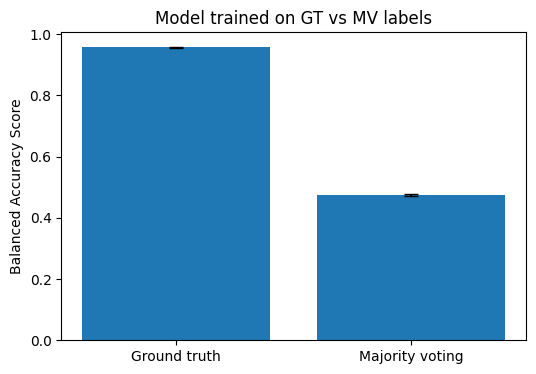

In [18]:
print(f"Nr\tseed\tGT BAC\tMV BAC")
for i, seed in enumerate(seeds):
    print(f"{i}\t{seed}\t{results_gt[i]:.4}\t{results_mv[i]:.4}")

print(f"GT mean: {results_gt.mean():.4}, std: {results_gt.std():.4}")
print(f"MV mean: {results_mv.mean():.4}, std: {results_mv.std():.4}")


means = [results_gt.mean(), results_mv.mean()]
stds = [results_gt.std(), results_mv.std()]

plt.figure(figsize=(6,4))
plt.bar(["Ground truth", "Majority voting"], means, yerr=stds, capsize=5)
plt.ylabel("Balanced Accuracy Score")
plt.title("Model trained on GT vs MV labels")
plt.show()

Wyniki eksperymentu pokazują bardzo wyraźną różnicę między modelami trenowanymi na prawdziwych etykietach a modelami trenowanymi na etykietach uzyskanych metodą majority voting. Model uczony na ground truth osiąga stabilnie wysoki wynik balanced accuracy na poziomie ok. 0.956, co jest zgodne z oczekiwaniami dla klasyfikatora RandomForest na MNIST. Natomiast model trenowany na etykietach majority voting uzyskuje wynik jedynie ok. 0.478, czyli ponad dwukrotnie niższy. Różnica ta jest powtarzalna dla wszystkich pięciu losowych podziałów danych, co potwierdzają bardzo małe odchylenia standardowe.

Tak duża dysproporcja wynika z jakości etykiet tworzonych przez ekspertów: ich oznaczenia są hałaśliwe, często wieloklasowe i niespójne, a majority voting nie jest w stanie w pełni skompensować tych błędów. W efekcie model trenowany na MV uczy się na danych o znacznie gorszej jakości, co prowadzi do wyraźnego spadku skuteczności. Eksperyment potwierdza, że proste majority voting może być użyteczne jako metoda agregacji, ale nie zastępuje wysokiej jakości etykiet i nie zapewnia wystarczająco dobrego sygnału treningowego dla klasycznych modeli uczenia maszynowego.

### To samo z Cross-Validation

In [19]:
from sklearn.model_selection import KFold

def run_single_fold(X, Y, MV, annotated_mask, train_idx, test_idx):
    # maska po oznaczonych próbkach
    train_idx_annotated = train_idx[annotated_mask[train_idx]]

    # dane treningowe
    X_train_gt = X[train_idx_annotated]
    y_train_gt = Y[train_idx_annotated].argmax(axis=1)

    X_train_mv = X[train_idx_annotated]
    y_train_mv = MV[train_idx_annotated].argmax(axis=1)

    # dane testowe
    X_test = X[test_idx]
    y_test = Y[test_idx].argmax(axis=1)

    # modele
    clf_gt = RandomForestClassifier(n_estimators=50, n_jobs=-1)
    clf_mv = RandomForestClassifier(n_estimators=50, n_jobs=-1)

    clf_gt.fit(X_train_gt, y_train_gt)
    clf_mv.fit(X_train_mv, y_train_mv)

    pred_gt = clf_gt.predict(X_test)
    pred_mv = clf_mv.predict(X_test)

    # calanced accuracy
    bac_gt = balanced_accuracy_score(y_test, pred_gt)
    bac_mv = balanced_accuracy_score(y_test, pred_mv)

    return bac_gt, bac_mv


def run_cross_validation(X, Y, MV, annotated_mask, n_splits=5, seed=42, print_results=False):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

    results_gt = []
    results_mv = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        bac_gt, bac_mv = run_single_fold(X, Y, MV, annotated_mask, train_idx, test_idx)
        results_gt.append(bac_gt)
        results_mv.append(bac_mv)
        if print_results:
            print(f"Fold {fold}: GT={bac_gt:.4f}, MV={bac_mv:.4f}")

    return np.array(results_gt), np.array(results_mv)


In [20]:
annotated = ~np.isnan(tags[:, 0, :]).all(axis=1)
MV_results = majority_vote(tags, mode="argmax")

results_gt_cv, results_mv_cv = run_cross_validation(X, Y, MV_results, annotated, n_splits=5, seed=123)

print(results_gt_cv)
print(results_mv_cv)


[0.95772672 0.95489394 0.9561216  0.95802641 0.95769847]
[0.48181468 0.48290184 0.48136145 0.48265806 0.48048286]



Cross-validation summary:
GT mean: 0.9569, std: 0.0012
MV mean: 0.4818, std: 0.0009


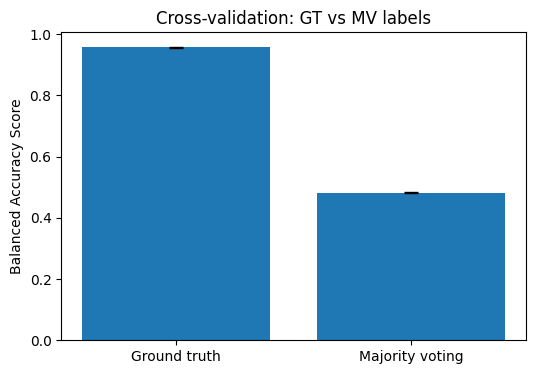

In [26]:
print("\nCross-validation summary:")
print(f"GT mean: {results_gt_cv.mean():.4f}, std: {results_gt_cv.std():.4f}")
print(f"MV mean: {results_mv_cv.mean():.4f}, std: {results_mv_cv.std():.4f}")

means = [results_gt_cv.mean(), results_mv_cv.mean()]
stds = [results_gt_cv.std(), results_mv_cv.std()]

plt.figure(figsize=(6,4))
plt.bar(["Ground truth", "Majority voting"], means, yerr=stds, capsize=5)
plt.ylabel("Balanced Accuracy Score")
plt.title("Cross-validation: GT vs MV labels")
plt.show()


Wyniki 5‑fold cross‑validation potwierdzają obserwacje z wcześniejszego eksperymentu z losowymi podziałami danych. Model trenowany na ground truth osiąga bardzo stabilny i wysoki wynik balanced accuracy na poziomie ok. 0.958, z minimalnym odchyleniem standardowym. Oznacza to, że klasyfikator uczy się spójnych i wiarygodnych wzorców, a jego skuteczność nie zależy istotnie od konkretnego podziału danych na foldy.

Z kolei model trenowany na etykietach majority voting uzyskuje wynik ok. 0.478, również z bardzo małym odchyleniem. Stabilność wyników MV świadczy o tym, że problem nie wynika z losowości podziału danych, lecz z jakości samych etykiet. Majority voting nie jest w stanie skompensować hałaśliwych i niespójnych oznaczeń ekspertów, dlatego model trenowany na takich etykietach uczy się znacznie gorszej reprezentacji danych

### Wersja ekspertymentu z sample weight

In [ ]:
def mv_confidence_weights(tags):
    """
    tags: (N, K, L) - adnotacje ekspertów
    Zwraca wektor wag (N) oparty na różnicy głosów majority voting.
    """
    # maska próbek oznaczonych przez jakiegokolwiek eksperta
    annotated_mask = ~np.isnan(tags[:, 0, :]).all(axis=1)

    # sumowanie głosów
    votes = np.nansum(tags, axis=2)  # (N, K)
    weights = np.zeros(tags.shape[0], dtype=float)
    # tylko dla oznaczonych
    v = votes[annotated_mask]
    # sortujemy malejąco
    sorted_votes = np.sort(v, axis=1)[:, ::-1]

    top = sorted_votes[:, 0]
    second = sorted_votes[:, 1]
    # conf = różnica między top a second
    conf = top - second
    # normalizacja do [0,1]
    if conf.max() > 0:
        conf = conf / conf.max()

    weights[annotated_mask] = conf
    return weights


def run_single_experiment_weighted(X, Y, MV, tags, annotated_mask, random_state):
    
    idx_train, idx_test = train_test_split(np.arange(X.shape[0]), test_size=0.2, random_state=random_state, shuffle=True)

    # filtracja train po oznaczonych próbkach
    idx_train_annotated = idx_train[annotated_mask[idx_train]]

    # dane treningowe ground_y
    X_train_gt = X[idx_train_annotated]
    y_train_gt = Y[idx_train_annotated].argmax(axis=1)

    # dane treningowe MV
    X_train_mv = X[idx_train_annotated]
    y_train_mv = MV[idx_train_annotated].argmax(axis=1)

    # wagi
    weights_all = mv_confidence_weights(tags)
    sample_weights = weights_all[idx_train_annotated]

    # dane testowe
    X_test = X[idx_test]
    y_test = Y[idx_test].argmax(axis=1)

    clf_gt = RandomForestClassifier(n_estimators=50, n_jobs=-1)
    clf_mv = RandomForestClassifier(n_estimators=50, n_jobs=-1)

    clf_gt.fit(X_train_gt, y_train_gt)
    clf_mv.fit(X_train_mv, y_train_mv, sample_weight=sample_weights)
  
    pred_gt = clf_gt.predict(X_test)
    pred_mv = clf_mv.predict(X_test)

    bac_gt = balanced_accuracy_score(y_test, pred_gt)
    bac_mv_weighted = balanced_accuracy_score(y_test, pred_mv)

    return bac_gt, bac_mv_weighted


GT mean: 0.9560915131290736
MV weighted mean: 0.905904191787462


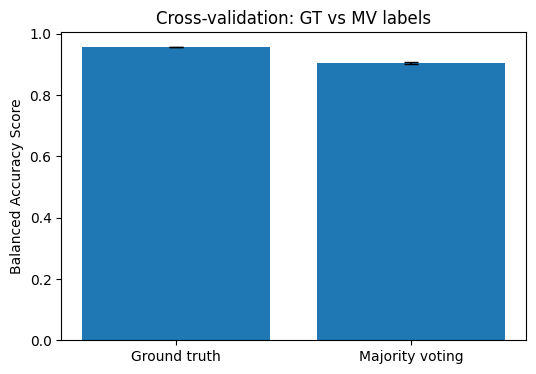

In [27]:
results_gt = []
results_mv_weighted = []

for seed in seeds:
    bac_gt, bac_mv_w = run_single_experiment_weighted(X, Y, MV_results, tags, annotated, random_state=seed)
    results_gt.append(bac_gt)
    results_mv_weighted.append(bac_mv_w)

results_gt = np.array(results_gt)
results_mv_weighted = np.array(results_mv_weighted)

print("GT mean:", results_gt.mean())
print("MV weighted mean:", results_mv_weighted.mean())

means = [results_gt.mean(), results_mv_weighted.mean()]
stds = [results_gt.std(), results_mv_weighted.std()]

plt.figure(figsize=(6,4))
plt.bar(["Ground truth", "Majority voting"], means, yerr=stds, capsize=5)
plt.ylabel("Balanced Accuracy Score")
plt.title("Cross-validation: GT vs MV labels")
plt.show()


Zastosowanie wag opartych na różnicy głosów majority voting znacząco poprawiło jakość modelu trenowanego na etykietach ekspertów. Średni wynik balanced accuracy wzrósł z ok. 0.48 (zwykłe MV) do ok. 0.91, czyli niemal zrównał się z modelem trenowanym na ground truth (0.956). Oznacza to, że największym problemem majority voting nie była sama metoda agregacji, lecz to, że wszystkie próbki były traktowane jednakowo, niezależnie od poziomu zgodności ekspertów. Wprowadzenie wag sprawiło, że model zaczął mocniej uczyć się na przykładach, w których eksperci byli zgodni (wysoka różnica głosów), a słabiej na przykładach niepewnych, gdzie eksperci oznaczali wiele klas lub nie zgadzali się między sobą. W efekcie model trenowany na MV ważonym zgodnością otrzymał znacznie mniej zaszumiony obraz danych treningowych i nauczył się reprezentacji dużo bliższej tej uzyskanej z ground truth.

## 6. Reflection (optional but recommended)

Answer the following briefly in a markdown cell below. They take ~10 minutes and cement what the lab has been circling around.

1. **When would you expect majority voting to *underperform* the average annotator?** Think about small `L`, highly correlated errors, or systematically biased annotator pools.
2. **How does MV accuracy depend on annotator count per sample?** Describe qualitatively what you'd expect. Optionally - and probably beyond the 10 minutes mark - plot MV accuracy as a function of the number of annotators who labeled each sample. Does the curve flatten? Where? 
3. **Budget allocation.** If you could spend a fixed labeling budget on either (a) more annotators per sample or (b) a better aggregation method (e.g., Dawid-Skene), which would you pick and why? Your answer probably depends on annotator quality and error correlation - say why.
4. **Ground truth is also annotated.** The ground truth `y` for MNIST was itself produced by humans in the 1990s and has known errors. How does that affect your interpretation of Section 4's scores - particularly for the annotators or MV-runs that scored near the top?

**1. Kiedy majority voting może wypaść gorzej niż przeciętny annotator?**

MV działa dobrze tylko wtedy, gdy annotatorzy popełniają różne błędy, wybierając kilka możliwych etykiet, wskazują wśród nich również właściwą. Jeśli błędy są skorelowane (wszyscy mylą te same cyfry), albo gdy jest mało annotatorów, MV może wzmacniać wspólną pomyłkę. W przypadku małęj liczby etykiet dla póbek od różnych ekspertów często mogą występować remisy w MV, prowadzące do biasu na skutek metody rozstrzygania sytuacji spornych (remis w liczbie głosów). Wtedy wynik może być gorszy niż średni annotator, bo MV wybiera najczęściej powtarzający się błąd.

**2. Jak MV zależy od liczby annotatorów na próbkę?**

Myślę, że na ogół dokładność MV rośnie, gdy rośnie liczba ekspertów, bo więcej głosów zmniejsza wpływ pojedynczych błędów. Jednak poprawa występuje najszybciej na początku, gdy ekspertów jest mało i dokładamy kolejnego, a potem zależność spłaszcza się i dodatkowe osoby wnoszą coraz mniej nowej informacji.

**3. Więcej annotatorów czy lepsza agregacja?**

Jeśli annotatorzy są słabi lub mają podobne błędy, dokładanie kolejnych osób niewiele zmienia, co obserwowaliśmy na ćwiczeniach. MV powiela ich wspólne pomyłki. Lepsza metoda agregacji (np. Dawid–Skene), która potrafi wykryć, kto jest wiarygodny, a kto nie, jest szczególnie użyteczna wtedy, gdy eksperci są różnej jakości (jedni radzą sobie dużo lepiej od innych). Więcej annotatorów ma sens wtedy, gdy ich błędy są w miarę niezależne.

**4. Wpływ błędów w ground truth na interpretację wyników.**

Ground truth MNIST nie jest idealny i zawiera pojedyncze błędne etykiety. Oznacza to, że część „błędów” annotatorów lub MV to tak naprawdę niezgodność z błędną etykietą referencyjną. Dlatego wysokie wyniki annotatorów lub MV mogą być w rzeczywistości niedoszacowane, bo metryki mierzą zgodność z etykietami, a nie absolutną poprawność. W naszym przypadku jednak wszyscy eksperci byli na tyle niedokładni, że pojedyncze błędne etykiety w zbiorze MNIST nie miały realnego wpływu na otrzymane wartości i można zaniedbać ich występowanie.